In [25]:
# Model 2 — High Value Customer Predictor
## Predicting whether a customer is a high value buyer

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import joblib
import json
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import optuna
import shap

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("All imports successful")

All imports successful


In [ ]:
BASE_DIR = Path().resolve().parent
conn = duckdb.connect(str(BASE_DIR / "data/warehouse/olist.duckdb"))

df_orders = conn.execute("""
    SELECT
        f.customer_id,
        f.order_id,
        f.total_price,
        f.total_freight,
        f.review_score,
        f.is_late,
        f.item_count,
        pay.payment_type,
        pay.payment_installments,
        c.customer_state
    FROM fact_orders f
    LEFT JOIN dim_payment pay ON f.order_id = pay.order_id
    LEFT JOIN dim_customer c ON f.customer_id = c.customer_id
    WHERE f.order_status = 'delivered'
""").df()

conn.close()

# Aggregate per customer
df_customers = df_orders.groupby("customer_id").agg(
    avg_order_value=("total_price", "mean"),
    avg_review_score=("review_score", "mean"),
    avg_freight=("total_freight", "mean"),
    late_rate=("is_late", "mean"),
    avg_installments=("payment_installments", "mean"),
    total_items=("item_count", "sum"),
    customer_state=("customer_state", "first"),
    payment_type=("payment_type", "first"),
    total_spent=("total_price", "sum")
).reset_index()

# Target: is this a high value customer?
# Target: will this customer give a high review score?
# High review = review score above 4
df_customers["is_satisfied"] = (
    df_customers["avg_review_score"] > 4
).astype(int)

print(f"Total customers : {len(df_customers):,}")
print(f"\nTarget distribution:")
print(df_customers["is_satisfied"].value_counts())

Total customers : 96,478
Median spend    : R$89.00

Target distribution:
is_high_value
0    48340
1    48138
Name: count, dtype: int64


In [28]:
# Fill nulls
df_customers["avg_review_score"] = df_customers["avg_review_score"].fillna(
    df_customers["avg_review_score"].median()
)
df_customers["avg_installments"] = df_customers["avg_installments"].fillna(1)
df_customers["late_rate"] = df_customers["late_rate"].fillna(0)
df_customers["customer_state"] = df_customers["customer_state"].fillna("unknown")
df_customers["payment_type"] = df_customers["payment_type"].fillna("unknown")

# Feature: freight ratio
df_customers["freight_ratio"] = (
    df_customers["avg_freight"] / (df_customers["avg_order_value"] + 1)
)

# Encode categoricals
le = LabelEncoder()
df_customers["customer_state"] = le.fit_transform(
    df_customers["customer_state"].astype(str)
)
df_customers["payment_type"] = le.fit_transform(
    df_customers["payment_type"].astype(str)
)

print("Feature engineering complete")
print(f"Dataset shape: {df_customers.shape}")

Feature engineering complete
Dataset shape: (96478, 12)


In [ ]:
FEATURES = [
    "avg_order_value", "avg_freight",
    "late_rate", "avg_installments", "total_items",
    "customer_state", "payment_type", "freight_ratio"
]

TARGET = "is_satisfied"

X = df_customers[FEATURES]
y = df_customers[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nClass distribution:")
print(y_train.value_counts())

Training set : (77182, 9)
Test set     : (19296, 9)

Class distribution:
is_high_value
0    38672
1    38510
Name: count, dtype: int64


In [30]:
# Model 1 — Logistic Regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Model 2 — XGBoost default
pipe_xgb = Pipeline([
    ("model", XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ))
])

# Model 3 — XGBoost tuned with Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss",
        "verbosity": 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(
        model, X_train, y_train,
        cv=3, scoring="roc_auc", n_jobs=-1
    ).mean()
    return score

print("Training Logistic Regression...")
pipe_lr.fit(X_train, y_train)

print("Training XGBoost default...")
pipe_xgb.fit(X_train, y_train)

print("Running Optuna tuning (50 trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(f"Best ROC-AUC: {study.best_value:.4f}")

pipe_xgb_tuned = Pipeline([
    ("model", XGBClassifier(
        **study.best_params,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ))
])
pipe_xgb_tuned.fit(X_train, y_train)
print("All models trained")

Training Logistic Regression...
Training XGBoost default...
Running Optuna tuning (50 trials)...
Best ROC-AUC: 1.0000
All models trained


MODEL COMPARISON — HIGH VALUE CUSTOMER PREDICTOR
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     97.83      97.69   97.97     97.83    99.71
    XGBoost Default     99.73      99.81   99.65     99.73   100.00
      XGBoost Tuned     99.75      99.89   99.62     99.75   100.00


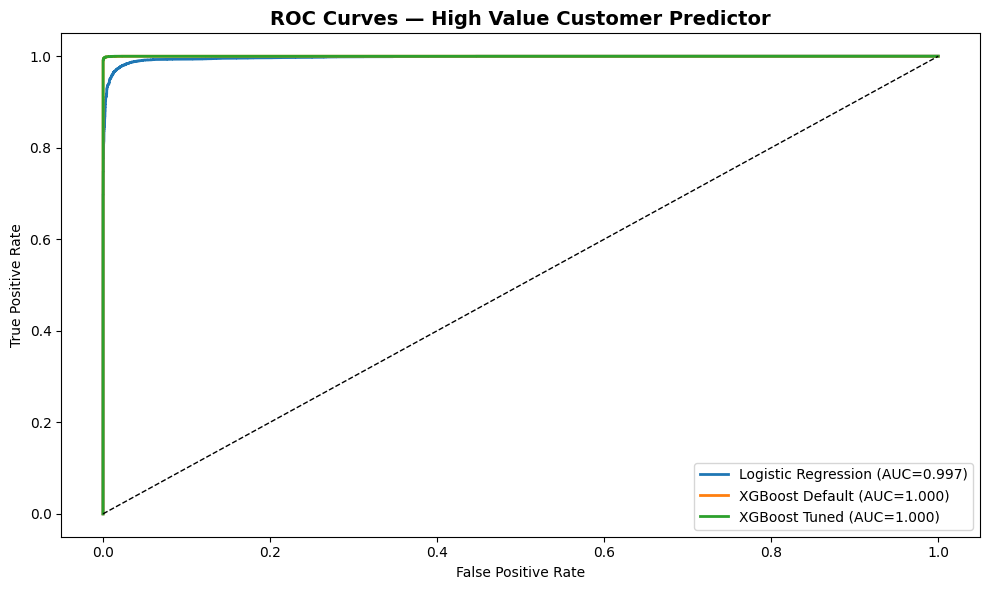

Chart saved


In [31]:
models = {
    "Logistic Regression": pipe_lr,
    "XGBoost Default":     pipe_xgb,
    "XGBoost Tuned":       pipe_xgb_tuned
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model":     name,
        "Accuracy":  round(report["accuracy"] * 100, 2),
        "Precision": round(report["1"]["precision"] * 100, 2),
        "Recall":    round(report["1"]["recall"] * 100, 2),
        "F1 Score":  round(report["1"]["f1-score"] * 100, 2),
        "ROC-AUC":   round(roc_auc * 100, 2)
    })

results_df = pd.DataFrame(results)
print("=" * 70)
print("MODEL COMPARISON — HIGH VALUE CUSTOMER PREDICTOR")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# ROC Curves
fig, ax = plt.subplots(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1], [0,1], "k--", linewidth=1)
ax.set_title("ROC Curves — High Value Customer Predictor",
             fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/15_highvalue_roc_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

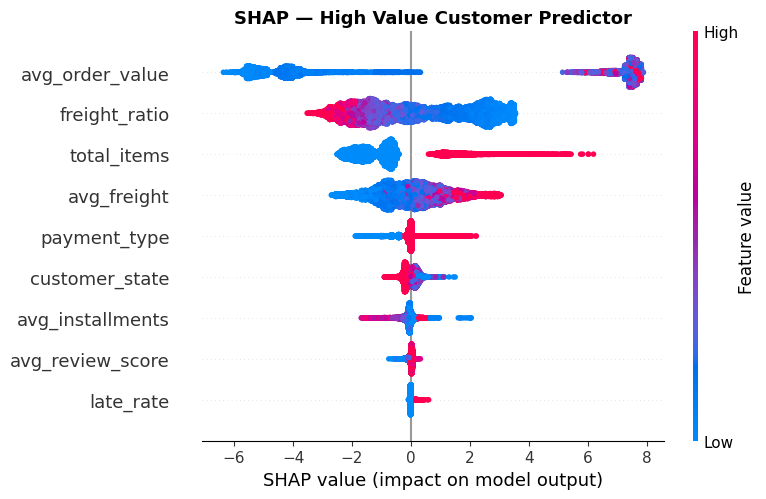

SHAP chart saved


In [32]:
xgb_model = pipe_xgb_tuned.named_steps["model"]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP — High Value Customer Predictor",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/16_highvalue_shap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("SHAP chart saved")

In [33]:
MODELS_DIR = BASE_DIR / "src/ml/saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipe_xgb_tuned, MODELS_DIR / "highvalue_predictor.pkl")

with open(MODELS_DIR / "highvalue_predictor_features.json", "w") as f:
    json.dump(FEATURES, f)

print("Model saved successfully")

Model saved successfully
